# Figure 5 — Monthly ML forcing

Monthly global RMS diagnostics for vertically integrated ML tendencies.


In [ ]:
from pathlib import Path
import importlib
import sys
import numpy as np
import xarray as xr
import dask
from dask.distributed import Client, get_client

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Run from ml_implement_paper/ or its notebooks/ directory')
sys.path.insert(0, str(PROJECT_ROOT))

from src import io as data_io
from src import metrics, plotting, preprocessing
plotting = importlib.reload(plotting)

config = data_io.load_config(PROJECT_ROOT / 'config' / 'paths.yaml')
analysis = config['analysis']

# ------------------------- User-adjustable settings -------------------------
OUTPUT_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag')
ML_ROOT = Path('/pscratch/sd/z/zhan391/seacrogs_scratch/ml_method_2026')
REFERENCE_ROOT = Path('/pscratch/sd/z/zhan391/seacrogs_scratch/reference_nudge')
POST_SUBDIR = Path('post/atm/180x360_aave/ts/monthly/1yr')
PERIOD = '201201_201212'
FORCE_COMPUTE = False  # True: overwrite selected case caches.
TENDENCY_FILES = {
    'Nudge_U': 'Nudge_U_vint',
    'Nudge_V': 'Nudge_V_vint',
    'Nudge_T': 'Nudge_T_vint',
    'Nudge_Q': 'Nudge_Q_vint',
}
# Select cases here; comment out any experiment you do not want to plot.
CASE_DIRS = {
    'CTRL': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_CTRL',
    'UNET-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNET_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-IMT-C05': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15-PTAP100': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_PTAPUNI100HPA_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'REF': REFERENCE_ROOT / 'F20TR_ne30pg2_EC30to60E2r2_NDGUVTQ_IMT_3hr_pm-cpu_08-01-25',
}
FONT_SIZE = 14
FIGURE_SIZE = (12, 8)
LINE_WIDTH = 1.5
LEGEND_FRAME = False
FIGURE_TITLE = 'Monthly normalized vertically integrated ML forcing'
COLORS = {
    'CTRL': '#222222',
    'UNET-IMT': '#2878B5',
    'UNETXTR-IMT': '#D95319',
    'UNETXTR-IMT-A15': '#9467BD',
    'UNETXTR-IMT-C05': '#2CA02C',
    'UNETXTR-IMT-C05A15': '#8C564B',
    'UNETXTR-LCZ-C05A15': '#17BECF',
    'UNETXTR-LCZ-C05A15-PTAP100': '#E377C2',
    'REF': '#7F7F7F',
}
# ---------------------------------------------------------------------------

paths = {
    'processed': OUTPUT_ROOT / 'processed',
    'figures': OUTPUT_ROOT / 'figures',
    'tables': OUTPUT_ROOT / 'tables',
}
for output_dir in paths.values():
    output_dir.mkdir(parents=True, exist_ok=True)
DIAGNOSTIC_DIR = paths['processed'] / 'monthly_ml_forcing'
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)
if not CASE_DIRS:
    raise ValueError('Select at least one experiment in CASE_DIRS')
ANALYSIS_CASES = tuple(name for name in CASE_DIRS if name != 'CTRL')
DIAGNOSTIC_PATHS = {name: DIAGNOSTIC_DIR / f'{name}_{PERIOD}.nc' for name in ANALYSIS_CASES}

def cache_is_compatible(path, experiment):
    if not path.exists():
        return False
    try:
        with xr.open_dataset(path) as cached:
            tendencies = set(cached['tendency'].values.astype(str))
            experiments = set(cached['experiment'].values.astype(str))
            required_data = {'tendency_rms', 'normalized_tendency_rms'}
            return (
                set(TENDENCY_FILES).issubset(tendencies)
                and experiment in experiments
                and required_data.issubset(cached.data_vars)
            )
    except (KeyError, OSError, ValueError):
        return False

CASES_TO_COMPUTE = tuple(
    name for name, path in DIAGNOSTIC_PATHS.items()
    if FORCE_COMPUTE or not cache_is_compatible(path, name)
)
RECOMPUTE = bool(CASES_TO_COMPUTE)
client = None
if RECOMPUTE:
    try:
        client = get_client()
    except ValueError:
        client = Client(n_workers=4, threads_per_worker=1, processes=False, dashboard_address=':0')


## Load and quality-check monthly tendency products


In [2]:
files = {}
input_modes = {}
missing = {}
for case in CASES_TO_COMPUTE:
    case_dir = CASE_DIRS[case]
    processed = [
        case_dir / POST_SUBDIR / f'{source}_{PERIOD}.nc'
        for source in TENDENCY_FILES.values()
    ]
    if all(path.exists() for path in processed):
        files[case] = processed
        input_modes[case] = 'postprocessed tendency files'
        continue
    model_outputs = sorted((case_dir / 'run').glob(f'*.eam.h0.{PERIOD[:4]}-??.nc'))
    if model_outputs:
        files[case] = model_outputs
        input_modes[case] = 'native monthly h0 files'
    else:
        missing[case] = list(TENDENCY_FILES.values())
if missing:
    details = '\n'.join(f"  {case}: {', '.join(tendencies)}" for case, tendencies in missing.items())
    raise FileNotFoundError('Postprocess the monthly vertically integrated tendencies first:\n' + details)

chunks = {'time': 12, 'lat': 45, 'lon': 90}
datasets = {} if RECOMPUTE else None
for case, case_files in files.items():
    opened = [xr.open_dataset(path, chunks=chunks, cache=False) for path in case_files]
    if input_modes[case] == 'postprocessed tendency files':
        dataset = xr.merge(opened, join='exact', compat='no_conflicts')
    else:
        source_names = list(TENDENCY_FILES.values())
        absent = [source for source in source_names if source not in opened[0]]
        if absent:
            raise KeyError(f"{case} native h0 output lacks: {', '.join(absent)}")
        dataset = xr.concat(
            [ds[source_names] for ds in opened], dim='time',
            data_vars='minimal', coords='minimal', compat='override', join='exact',
        ).sortby('time')
    datasets[case] = dataset.rename({source: tendency for tendency, source in TENDENCY_FILES.items()})
datasets = {
    case: preprocessing.subset_time(ds, analysis['start_date'], analysis['end_date'])
    for case, ds in datasets.items()
} if RECOMPUTE else None
datasets = preprocessing.match_common_times(datasets) if RECOMPUTE else None

status = (
    {'mode': 'compute', 'cases': CASES_TO_COMPUTE, 'input_modes': input_modes, 'datasets': {name: dict(ds.sizes) for name, ds in datasets.items()}}
    if RECOMPUTE else
    {'mode': 'cached', 'paths': {name: str(path) for name, path in DIAGNOSTIC_PATHS.items()}}
)

qc_keys = []
qc_tasks = []
for case, ds in datasets.items() if RECOMPUTE else []:
    for tendency in TENDENCY_FILES:
        qc_keys.append((case, tendency))
        qc_tasks.extend([
            np.isfinite(ds[tendency]).any().data,
            (~np.isfinite(ds[tendency])).sum().data,
        ])
qc_values = dask.compute(*qc_tasks)
qc = {}
for index, key in enumerate(qc_keys):
    has_finite = bool(qc_values[2 * index])
    invalid_count = int(qc_values[2 * index + 1])
    if not has_finite:
        raise ValueError(f'{key[0]}:{key[1]} contains no finite values')
    qc.setdefault(key[0], {})[key[1]] = invalid_count
status, qc
qc


{'UNET-IMT': {'Nudge_U': 0, 'Nudge_V': 0, 'Nudge_T': 0, 'Nudge_Q': 0},
 'UNETXTR-IMT': {'Nudge_U': 0, 'Nudge_V': 0, 'Nudge_T': 0, 'Nudge_Q': 0},
 'UNETXTR-IMT-A15': {'Nudge_U': 0, 'Nudge_V': 0, 'Nudge_T': 0, 'Nudge_Q': 0},
 'UNETXTR-IMT-C05': {'Nudge_U': 0, 'Nudge_V': 0, 'Nudge_T': 0, 'Nudge_Q': 0},
 'UNETXTR-IMT-C05A15': {'Nudge_U': 0,
  'Nudge_V': 0,
  'Nudge_T': 0,
  'Nudge_Q': 0},
 'UNETXTR-LCZ-C05A15': {'Nudge_U': 0,
  'Nudge_V': 0,
  'Nudge_T': 0,
  'Nudge_Q': 0},
 'REF': {'Nudge_U': 0, 'Nudge_V': 0, 'Nudge_T': 0, 'Nudge_Q': 0}}

## Derive and save the monthly forcing diagnostic


In [3]:
if RECOMPUTE:
    for case, ds in datasets.items():
        sample = ds[next(iter(TENDENCY_FILES))].isel(time=0, drop=True)
        area = np.cos(np.deg2rad(sample['lat'])).clip(min=0).broadcast_like(sample)
        area = area / area.sum()
        by_tendency = [
            np.sqrt(metrics.weighted_mean(ds[tendency] ** 2, area, list(area.dims)))
            for tendency in TENDENCY_FILES
        ]
        tendency_rms = xr.concat(
            by_tendency, dim=xr.IndexVariable('tendency', list(TENDENCY_FILES))
        ).rename('tendency_rms')
        normalized = (tendency_rms / tendency_rms.mean('time', skipna=True)).rename('normalized_tendency_rms')
        case_diagnostic = xr.Dataset({
            'tendency_rms': tendency_rms,
            'normalized_tendency_rms': normalized,
        }).expand_dims(experiment=[case])
        case_diagnostic.attrs.update({
            'experiment': case, 'period': PERIOD, 'case_directory': str(CASE_DIRS[case]),
        })
        data_io.save_dataset(case_diagnostic, DIAGNOSTIC_PATHS[case])

diagnostic = xr.concat(
    [xr.open_dataset(DIAGNOSTIC_PATHS[name]) for name in ANALYSIS_CASES], dim='experiment'
)
diagnostic


<xarray.Dataset> Size: 6kB
Dimensions:                  (experiment: 7, tendency: 4, time: 11)
Coordinates:
  * experiment               (experiment) <U18 504B 'UNET-IMT' ... 'REF'
  * tendency                 (tendency) <U7 112B 'Nudge_U' ... 'Nudge_Q'
  * time                     (time) object 88B 2012-02-01 00:00:00 ... 2012-1...
Data variables:
    tendency_rms             (experiment, tendency, time) float64 2kB 0.03944...
    normalized_tendency_rms  (experiment, tendency, time) float64 2kB 0.9504 ...
Attributes:
    experiment:      UNET-IMT
    period:          201201_201212
    case_directory:  /pscratch/sd/z/zhan391/seacrogs_scratch/ml_method_2026/F...

## Plot the monthly forcing diagnostic


PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/figures/fig05_monthly_ml_forcing.png')

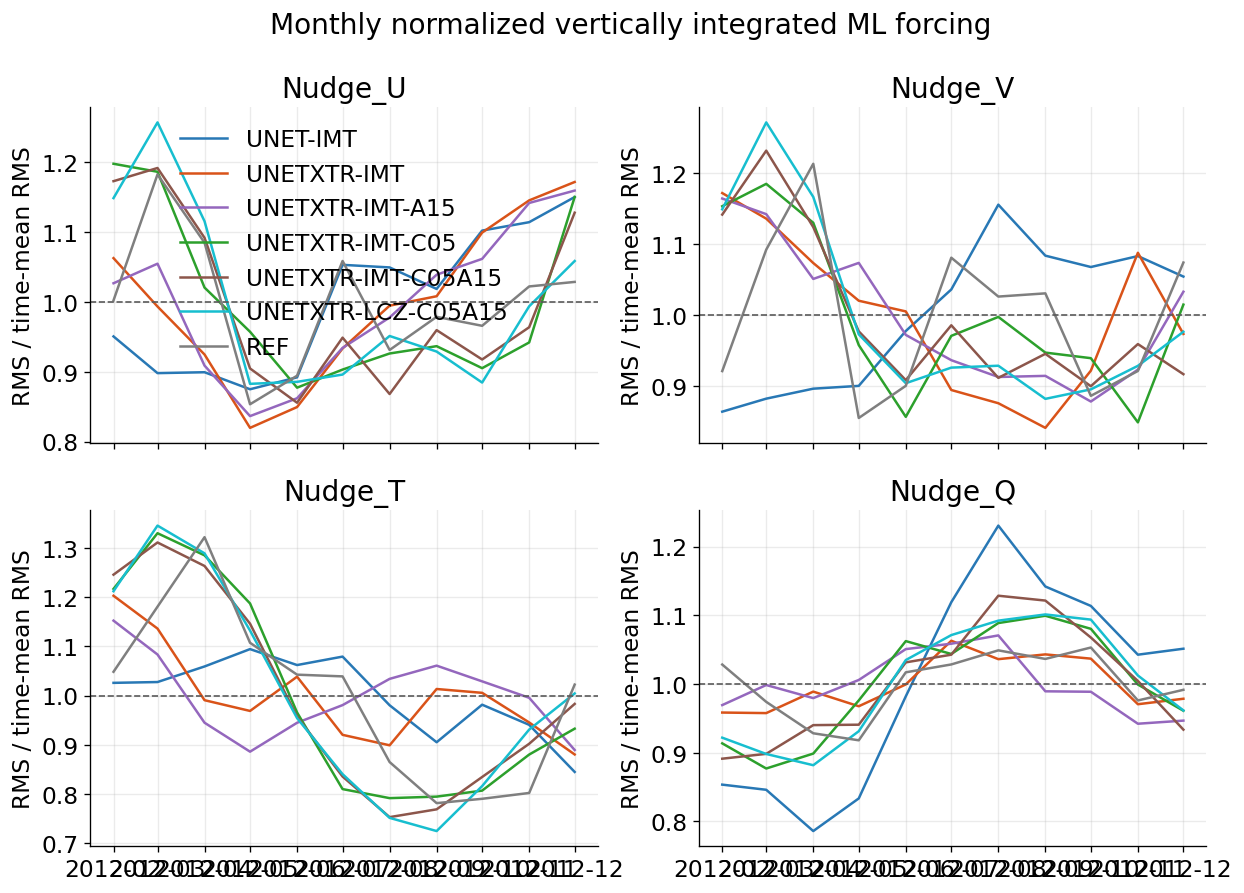

In [4]:
FIGURE_PATH = paths['figures'] / 'fig05_monthly_ml_forcing.png'
diagnostic = xr.concat(
    [xr.open_dataset(DIAGNOSTIC_PATHS[name]) for name in ANALYSIS_CASES], dim='experiment'
)
plotting.plot_monthly_ml_forcing(
    diagnostic, FIGURE_PATH,
    figsize=FIGURE_SIZE,
    colors=COLORS,
    title=FIGURE_TITLE,
    legend_frame=LEGEND_FRAME,
    linewidth=LINE_WIDTH,
    font_size=FONT_SIZE,
)
